# Disciplina de Inteligência Artificial , Professor Munif , Unicesumar 2026

## Projeto Final — Classificação de Potabilidade da Água

**Integrantes:**
- Vinicius Reginaldo Ferrarini — RA: 23159293-2
- Pedro Alvaro Mantuani Silva  — RA: 23079477-2
- Luiz Henrique Peschieira Romano  — RA: 25363238-2


---
## 1. Importação das Bibliotecas

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import load_model

os.makedirs('modelos', exist_ok=True)
os.makedirs('graficos', exist_ok=True)

print('Bibliotecas importadas com sucesso!')
print(f'TensorFlow versão: {tf.__version__}')

Bibliotecas importadas com sucesso!
TensorFlow versão: 2.20.0


---
## 2. Carregamento e Exploração do Dataset

In [12]:
# Carrega o dataset
# Certifique-se de que o arquivo 'water_quality.csv' está na pasta do projeto
df = pd.read_csv('water_quality.csv')

print('=== Informações do Dataset ===')
print(f'Registros: {df.shape[0]}')
print(f'Atributos: {df.shape[1]}')
print()
print('Primeiras linhas:')
df.head()

=== Informações do Dataset ===
Registros: 7999
Atributos: 21

Primeiras linhas:


,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [13]:
print('=== Tipos de dados e valores nulos ===')
print(df.info())
print()
print('=== Valores nulos por coluna ===')
print(df.isnull().sum())

=== Tipos de dados e valores nulos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   object 
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver   

Registros após limpeza: 7996
is_safe
0    7084
1     912
Name: count, dtype: int64
=== Distribuição da variável alvo (is_safe) ===
is_safe
0    7084
1     912
Name: count, dtype: int64

Amostras potáveis (1): 912
Amostras não potáveis (0): 7084


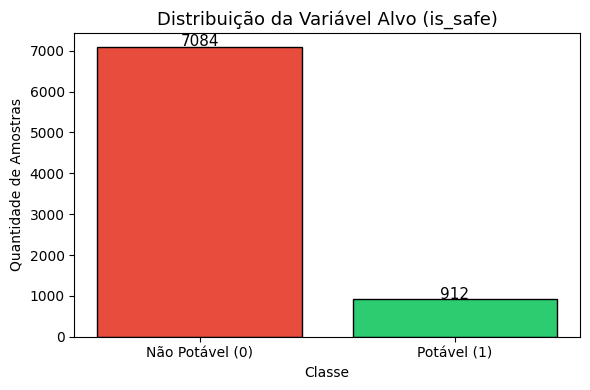

Gráfico salvo em graficos/distribuicao_classes.png


In [20]:
# Remove linhas com valores inválidos (#NUM!) na coluna is_safe
df = df[df['is_safe'] != '#NUM!']
df['is_safe'] = df['is_safe'].astype(int)

print(f'Registros após limpeza: {len(df)}')
print(df['is_safe'].value_counts())

print('=== Distribuição da variável alvo (is_safe) ===')
print(df['is_safe'].value_counts())
print()
print(f"Amostras potáveis (1): {df['is_safe'].sum()}")
print(f"Amostras não potáveis (0): {(df['is_safe'] == 0).sum()}")

# Gráfico de distribuição da variável alvo
plt.figure(figsize=(6, 4))
contagens = df['is_safe'].value_counts()
plt.bar(['Não Potável (0)', 'Potável (1)'], contagens.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Distribuição da Variável Alvo (is_safe)', fontsize=13)
plt.ylabel('Quantidade de Amostras')
plt.xlabel('Classe')
for i, v in enumerate(contagens.values):
    plt.text(i, v + 20, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('graficos/distribuicao_classes.png', dpi=150)
plt.show()
print('Gráfico salvo em graficos/distribuicao_classes.png')

---
## 3. Preparação dos Dados

In [21]:
# Remove linhas com valores nulos
df_limpo = df.dropna()
print(f'Registros antes da limpeza: {df.shape[0]}')
print(f'Registros após a limpeza:   {df_limpo.shape[0]}')
print(f'Registros removidos:        {df.shape[0] - df_limpo.shape[0]}')

Registros antes da limpeza: 7996
Registros após a limpeza:   7996
Registros removidos:        0


In [22]:
# Separação de features (X) e variável alvo (y)
X = df_limpo.drop(columns=['is_safe'])
y = df_limpo['is_safe']

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'\nAtributos utilizados:')
print(list(X.columns))

Features (X): (7996, 20)
Target  (y): (7996,)

Atributos utilizados:
['aluminium', 'ammonia', 'arsenic', 'barium', 'cadmium', 'chloramine', 'chromium', 'copper', 'flouride', 'bacteria', 'viruses', 'lead', 'nitrates', 'nitrites', 'mercury', 'perchlorate', 'radium', 'selenium', 'silver', 'uranium']


In [23]:
# Divisão treino/teste: 80% / 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')

Treino: 6396 amostras
Teste:  1600 amostras


In [24]:
# Normalização (StandardScaler — média 0, desvio padrão 1)
# O scaler é ajustado apenas no treino para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Normalização aplicada com sucesso!')
print(f'Média dos dados de treino após scaling: {X_train_scaled.mean():.4f}')
print(f'Desvio padrão após scaling: {X_train_scaled.std():.4f}')

Normalização aplicada com sucesso!
Média dos dados de treino após scaling: -0.0000
Desvio padrão após scaling: 1.0000


---
## 4. Modelo 1 — Naive Bayes (Parte 1 da Disciplina)

In [25]:
print('=== Treinando Naive Bayes Gaussiano ===')

modelo_nb = GaussianNB()
modelo_nb.fit(X_train_scaled, y_train)

print('Treinamento concluído!')

=== Treinando Naive Bayes Gaussiano ===
Treinamento concluído!


In [26]:
# Predições e métricas — Naive Bayes
y_pred_nb = modelo_nb.predict(X_test_scaled)

acc_nb  = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, zero_division=0)
rec_nb  = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb   = f1_score(y_test, y_pred_nb, zero_division=0)

print('=== Resultados — Naive Bayes ===')
print(f'Acurácia:  {acc_nb:.4f} ({acc_nb*100:.2f}%)')
print(f'Precisão:  {prec_nb:.4f}')
print(f'Recall:    {rec_nb:.4f}')
print(f'F1-Score:  {f1_nb:.4f}')
print()
print('=== Relatório Completo ===')
print(classification_report(y_test, y_pred_nb, target_names=['Não Potável', 'Potável']))

=== Resultados — Naive Bayes ===
Acurácia:  0.8444 (84.44%)
Precisão:  0.4169
Recall:    0.6150
F1-Score:  0.4970

=== Relatório Completo ===
              precision    recall  f1-score   support

 Não Potável       0.94      0.88      0.91      1400
     Potável       0.42      0.61      0.50       200

    accuracy                           0.84      1600
   macro avg       0.68      0.75      0.70      1600
weighted avg       0.88      0.84      0.86      1600



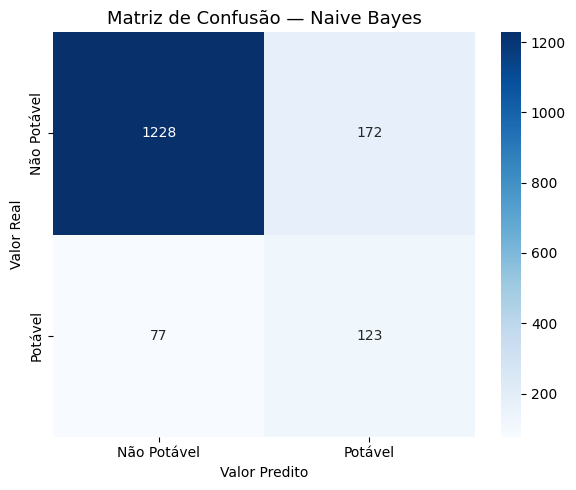

Gráfico salvo em graficos/matriz_confusao_nb.png


In [27]:
# Matriz de confusão — Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nb, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Não Potável', 'Potável'],
    yticklabels=['Não Potável', 'Potável']
)
plt.title('Matriz de Confusão — Naive Bayes', fontsize=13)
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.tight_layout()
plt.savefig('graficos/matriz_confusao_nb.png', dpi=150)
plt.show()
print('Gráfico salvo em graficos/matriz_confusao_nb.png')

In [28]:
# Salvar modelo Naive Bayes
joblib.dump(modelo_nb, 'modelos/modelo_naive_bayes.pkl')
print('Modelo Naive Bayes salvo em modelos/modelo_naive_bayes.pkl')

Modelo Naive Bayes salvo em modelos/modelo_naive_bayes.pkl


---
## 5. Modelo 2 — Rede Neural Artificial (Parte 2 da Disciplina)

In [29]:
# Definição da arquitetura da RNA
modelo_rna = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

modelo_rna.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo_rna.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
print('=== Treinando Rede Neural Artificial ===')

historico = modelo_rna.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print('\nTreinamento concluído!')

=== Treinando Rede Neural Artificial ===
Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8651 - loss: 0.3410 - val_accuracy: 0.9039 - val_loss: 0.2370
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9052 - loss: 0.2307 - val_accuracy: 0.9227 - val_loss: 0.2061
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9236 - loss: 0.1997 - val_accuracy: 0.9312 - val_loss: 0.1907
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9304 - loss: 0.1810 - val_accuracy: 0.9359 - val_loss: 0.1766
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9371 - loss: 0.1642 - val_accuracy: 0.9438 - val_loss: 0.1593
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9416 - loss: 0.1496 - val_accuracy: 0.9500 - val_loss: 0.1506
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9490 - loss: 0.1362 - val_accuracy: 0.9523 - val_loss: 0.1432
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

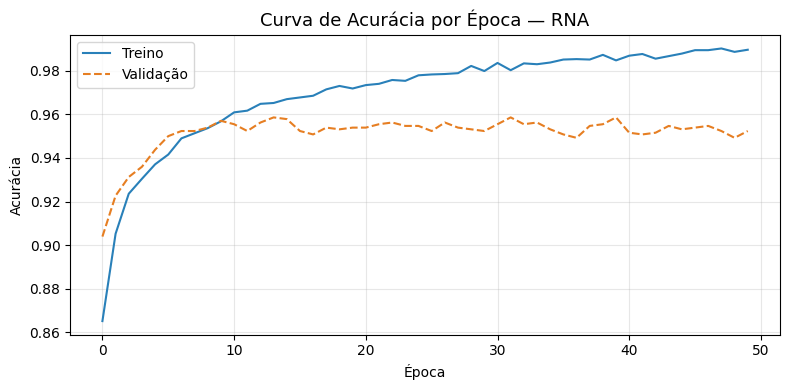

Gráfico salvo em graficos/curva_acuracia_rna.png


In [31]:
# Curva de Acurácia — RNA
plt.figure(figsize=(8, 4))
plt.plot(historico.history['accuracy'],     label='Treino',   color='#2980b9')
plt.plot(historico.history['val_accuracy'], label='Validação', color='#e67e22', linestyle='--')
plt.title('Curva de Acurácia por Época — RNA', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graficos/curva_acuracia_rna.png', dpi=150)
plt.show()
print('Gráfico salvo em graficos/curva_acuracia_rna.png')

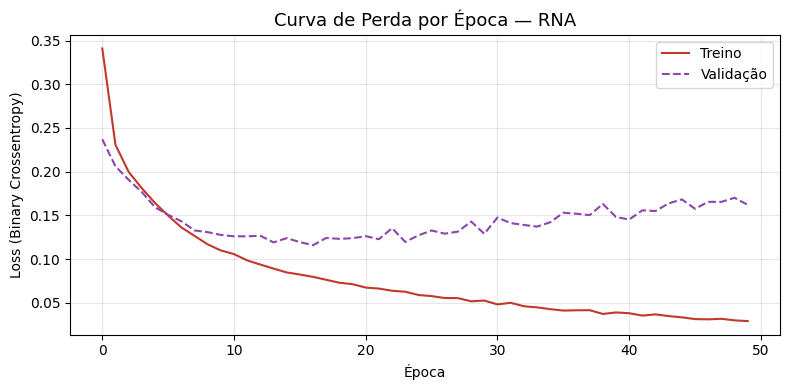

Gráfico salvo em graficos/curva_perda_rna.png


In [32]:
# Curva de Perda — RNA
plt.figure(figsize=(8, 4))
plt.plot(historico.history['loss'],     label='Treino',   color='#c0392b')
plt.plot(historico.history['val_loss'], label='Validação', color='#8e44ad', linestyle='--')
plt.title('Curva de Perda por Época — RNA', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graficos/curva_perda_rna.png', dpi=150)
plt.show()
print('Gráfico salvo em graficos/curva_perda_rna.png')

In [33]:
# Predições e métricas — RNA
y_prob_rna = modelo_rna.predict(X_test_scaled)
y_pred_rna = (y_prob_rna >= 0.5).astype(int).flatten()

acc_rna  = accuracy_score(y_test, y_pred_rna)
prec_rna = precision_score(y_test, y_pred_rna, zero_division=0)
rec_rna  = recall_score(y_test, y_pred_rna, zero_division=0)
f1_rna   = f1_score(y_test, y_pred_rna, zero_division=0)

print('=== Resultados — Rede Neural Artificial ===')
print(f'Acurácia:  {acc_rna:.4f} ({acc_rna*100:.2f}%)')
print(f'Precisão:  {prec_rna:.4f}')
print(f'Recall:    {rec_rna:.4f}')
print(f'F1-Score:  {f1_rna:.4f}')
print()
print('=== Relatório Completo ===')
print(classification_report(y_test, y_pred_rna, target_names=['Não Potável', 'Potável']))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
=== Resultados — Rede Neural Artificial ===
Acurácia:  0.9500 (95.00%)
Precisão:  0.8297
Recall:    0.7550
F1-Score:  0.7906

=== Relatório Completo ===
              precision    recall  f1-score   support

 Não Potável       0.97      0.98      0.97      1400
     Potável       0.83      0.76      0.79       200

    accuracy                           0.95      1600
   macro avg       0.90      0.87      0.88      1600
weighted avg       0.95      0.95      0.95      1600



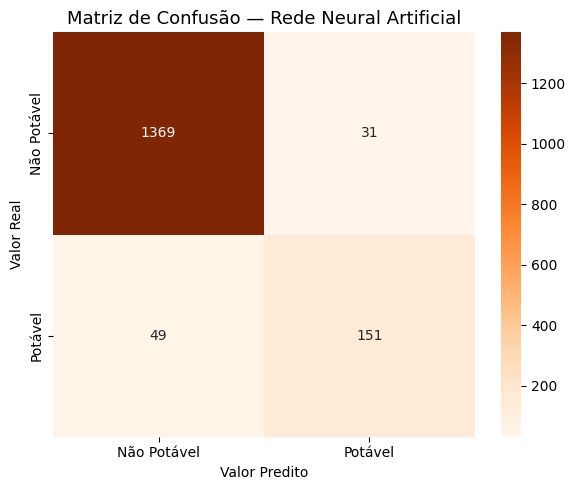

Gráfico salvo em graficos/matriz_confusao_rna.png


In [34]:
# Matriz de confusão — RNA
cm_rna = confusion_matrix(y_test, y_pred_rna)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rna, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Não Potável', 'Potável'],
    yticklabels=['Não Potável', 'Potável']
)
plt.title('Matriz de Confusão — Rede Neural Artificial', fontsize=13)
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.tight_layout()
plt.savefig('graficos/matriz_confusao_rna.png', dpi=150)
plt.show()
print('Gráfico salvo em graficos/matriz_confusao_rna.png')

In [35]:
# Salvar modelo RNA
modelo_rna.save('modelos/modelo_rna.h5')
print('Modelo RNA salvo em modelos/modelo_rna.h5')

Modelo RNA salvo em modelos/modelo_rna.h5


---
## 6. Comparação dos Modelos

In [36]:
# Tabela comparativa
resultados = pd.DataFrame({
    'Modelo':    ['Naive Bayes', 'Rede Neural (RNA)'],
    'Acurácia':  [round(acc_nb,  4), round(acc_rna,  4)],
    'Precisão':  [round(prec_nb, 4), round(prec_rna, 4)],
    'Recall':    [round(rec_nb,  4), round(rec_rna,  4)],
    'F1-Score':  [round(f1_nb,   4), round(f1_rna,   4)],
})

print('=== Comparação Final dos Modelos ===')
print(resultados.to_string(index=False))

=== Comparação Final dos Modelos ===
           Modelo  Acurácia  Precisão  Recall  F1-Score
      Naive Bayes    0.8444    0.4169   0.615    0.4970
Rede Neural (RNA)    0.9500    0.8297   0.755    0.7906


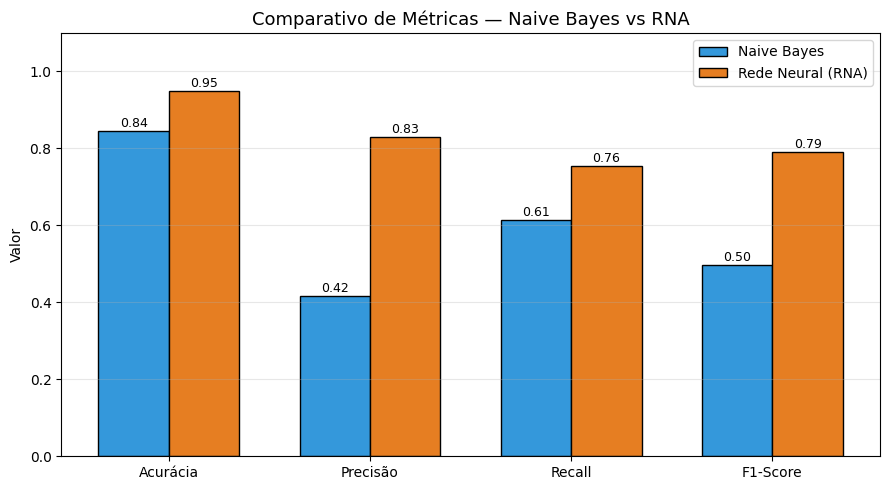

Gráfico salvo em graficos/comparativo_modelos.png


In [37]:
# Gráfico comparativo de métricas
metricas  = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
vals_nb   = [acc_nb,  prec_nb, rec_nb,  f1_nb]
vals_rna  = [acc_rna, prec_rna, rec_rna, f1_rna]

x = np.arange(len(metricas))
largura = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
barras_nb  = ax.bar(x - largura/2, vals_nb,  largura, label='Naive Bayes',       color='#3498db', edgecolor='black')
barras_rna = ax.bar(x + largura/2, vals_rna, largura, label='Rede Neural (RNA)', color='#e67e22', edgecolor='black')

ax.set_title('Comparativo de Métricas — Naive Bayes vs RNA', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for barra in barras_nb:
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.01,
            f'{barra.get_height():.2f}', ha='center', fontsize=9)
for barra in barras_rna:
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.01,
            f'{barra.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('graficos/comparativo_modelos.png', dpi=150)
plt.show()
print('Gráfico salvo em graficos/comparativo_modelos.png')

---
## 7. Carregando os Modelos Treinados (demonstração)

In [39]:
# Demonstração de como recarregar os modelos salvos
modelo_nb_carregado  = joblib.load('modelos/modelo_naive_bayes.pkl')
modelo_rna_carregado = load_model('modelos/modelo_rna.h5')

# Verificação rápida
y_check = modelo_nb_carregado.predict(X_test_scaled[:5])
print('Predições do Naive Bayes recarregado (5 primeiras amostras):')
print(y_check)
print('\nModelos carregados e funcionando corretamente!')

Predições do Naive Bayes recarregado (5 primeiras amostras):
[0 0 0 0 0]

Modelos carregados e funcionando corretamente!


---
*Disciplina de Inteligência Artificial — Professor Munif Gebara Junior — Unicesumar 2026*